# Plots

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from scripts.fingerprint_build import AudioExtract, FingerPrintBuild


## 1. Spectrogram plot 
A. Database Recording

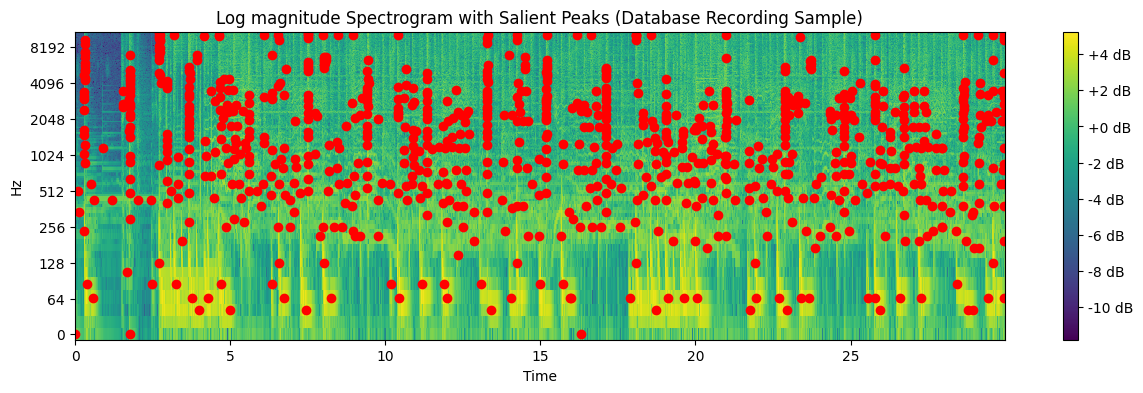

In [2]:
sr = 22050
n_fft = 1024
hop_length = n_fft // 2
window_sec = 1
spec = AudioExtract(sr, n_fft, hop_length)

database_dir = '../data/database_recordings/'
sample_file = os.path.join(database_dir, 'pop.00070.wav')

spec = AudioExtract(sr=sr, n_fft=n_fft, hop_length=hop_length)
y = spec.get_single_file(sample_file)

fp = FingerPrintBuild(y)
peaks = fp.get_salient_peaks(sr, n_fft, hop_length, target_peak_s = 30, window_sec=window_sec) 
bin_idx, frame_idx = zip(*peaks)

times = librosa.frames_to_time(frame_idx, sr=sr, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)[list(bin_idx)]

fig, ax = plt.subplots(1, 1, figsize=(15,4))
img = librosa.display.specshow(y, y_axis='log',x_axis='time',
                               sr=sr, ax=ax, cmap='viridis')

ax.scatter(x=times, y= freqs, c='red')
fig.colorbar(img, ax=ax, format='%+2.0f dB')                           
ax.set(title='Log magnitude Spectrogram with Salient Peaks (Database Recording Sample)')
plt.show()



B. Query Recording

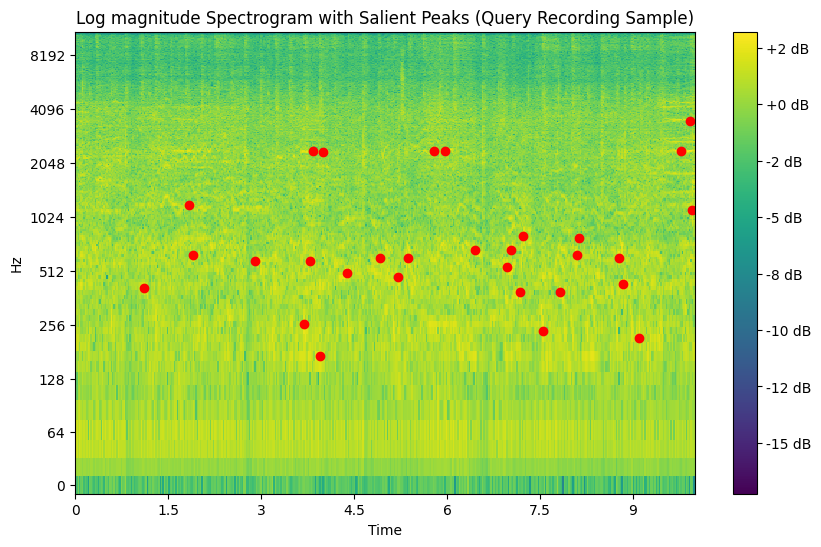

In [3]:
# sr_query = 44100
target_sr = 22050
window_length_query = int(0.064 * target_sr)
n_fft_query = 1024
hop_length_query = n_fft_query // 2

query_dir = '../data/query_recordings/'
sample_file_query = os.path.join(query_dir, 'pop.00070-snippet-10-10.wav')


specq = AudioExtract(sr=target_sr, n_fft=n_fft_query, hop_length=hop_length_query)
y_q = specq.get_single_file(sample_file_query)

fp = FingerPrintBuild(y_q)
q_peaks = fp.get_salient_peaks(target_sr, n_fft_query, hop_length_query, target_peak_s = 30, window_sec=window_length_query) 
q_bin_idx, q_frame_idx = zip(*q_peaks)


qtimes = librosa.frames_to_time(q_frame_idx, sr=sr, hop_length=hop_length)
qfreqs = librosa.fft_frequencies(sr=target_sr, n_fft=n_fft_query)[list(q_bin_idx)]

figq, axq = plt.subplots(1, 1, figsize=(10,6))
imgq = librosa.display.specshow(y_q, y_axis='log',x_axis='time',
                               sr=target_sr, ax=axq, cmap='viridis')

axq.scatter(x=qtimes, y= qfreqs, c='red')
figq.colorbar(imgq, ax=axq, format='%+2.0f dB')                           
axq.set(title='Log magnitude Spectrogram with Salient Peaks (Query Recording Sample)')
plt.show()


